In [ ]:
import specpolFlow as pol
import matplotlib.pyplot as plt
import VPtools as vp
import numpy as np
from pathlib import Path
import math



In [ ]:
path_google = 'G:/Shared drives/'

def make_binary_model_O(p):
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galB_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galB_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label
def make_binary_model_B(p): # B star
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galB_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galB_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label

def dopplershift_rotate(spectrum, dopplershift, vsini):
    shifted_spectrum = spectrum.doppler_shift(dopplershift)
    convolved_spectrum = shifted_spectrum.convolveRot(vsini, 0.5)
    return convolved_spectrum


In [ ]:
obs_folder = Path(r"G:\Shared drives\BinamicsOstars\DataFromEve\spectra_tovero")
name = "hd144218_H_55705.26306009pn_rn.s"

spec = pol.read_spectrum(obs_folder / f"{name}")
# spec = pol.read_spectrum(
#     r"G:\Shared drives\BinamicsOstars\DataFromEve\spectra_tovero/hd139365_H_55706.21013097pn_rn.s")
path_google = 'G:\Shared drives\\'


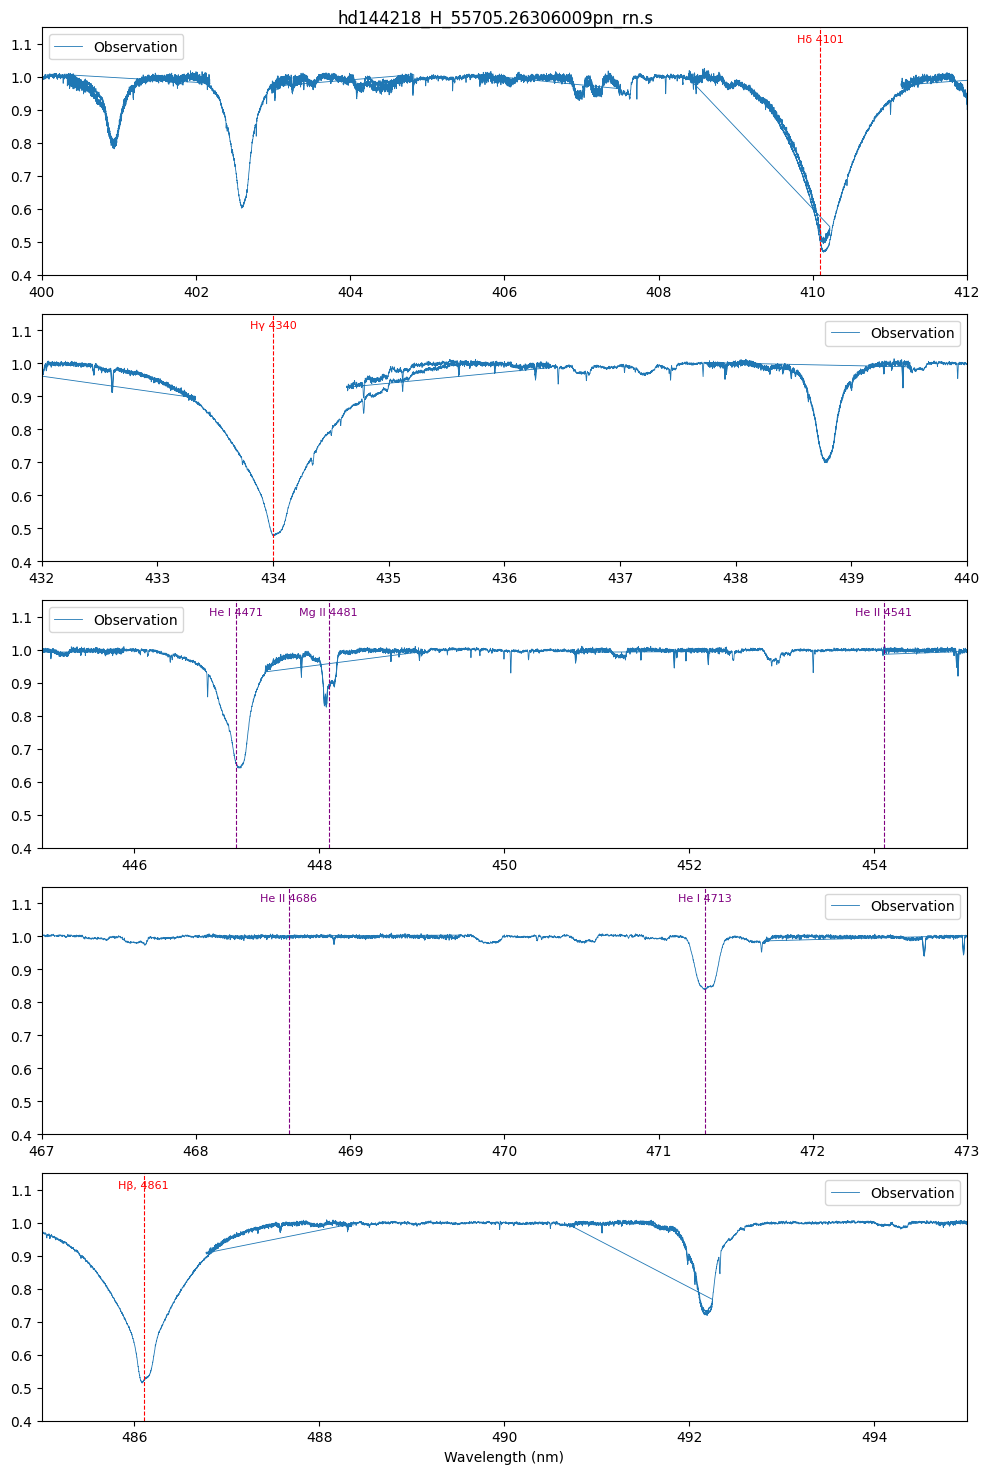

In [ ]:
windows = [(400,412), (432,440), (445,455), (467,473), (485,495)]


lines_H = [
    (410.1, 'Hδ 4101'),
    (434.0, "Hγ 4340"),
        (486.1, "Hβ, 4861")]
lines_He = [
    (447.1, "He I 4471"),
    (448.1, "Mg II 4481"),
    (454.1, "He II 4541"),
    (468.6, "He II 4686"),
    (471.3, "He I 4713"),
]
vrad = 50
vsini = 20

fig, ax = plt.subplots(len(windows), 1, figsize=(10, 3 * len(windows)))
for i, (xmin, xmax) in enumerate(windows):
    ax[i].plot(spec.wl, spec.specI, lw=0.6, label="Observation")
    # ax[i].plot(joint.wl/10, joint.specI,
            #    lw=0.8, label=synthetic_spec_1+'\n'+synthetic_spec_2)
    ax[i].set_xlim(xmin, xmax)
    ax[i].set_ylim(0.4, 1.15)
    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl,color='red',ls='--',lw=0.8)
            ax[i].text(wl,1.1,label,color='red', ha='center',va='bottom',fontsize=8)
    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl,color='purple',ls='--',lw=0.8)
            ax[i].text(wl,1.1,label,color='purple', ha='center',va='bottom',fontsize=8)
    ax[i].legend()
ax[-1].set_xlabel("Wavelength (nm)")
fig.suptitle(f"{name}")
# fig.suptitle(f"{synthetic_spec_1}: vrad = {vrad1}, vsini = {vsini1} {synthetic_spec_2}: vrad = {vrad2}, vsini = {vsini2},R2/R1 = {R2R1}")
plt.tight_layout()
plt.show()


In [ ]:
# Teff — match the He I/He II ionization balance (e.g., 4200, 4471, 4541).
# log g — Balmer wings (Hδ, Hγ, Hβ). higher log g, broader wings
# vsini — match the widths of the helium and metal lines.

params = {"teff1": 18000, "logg1": 325, "vsini1": 100, "vrad1":-10,"R2R1": 1.0,"vturb": 2}
# ---------------- Load TLUSTY models ----------------
file_name_1 = f"G{params['teff1']}g{params['logg1']}v{params['vturb']}.vis"

my_model_name1 = vp.tlusty.galB_path_name.format(
    "vis",
    params["teff1"],
    params["logg1"],
    str(params["vturb"])
)



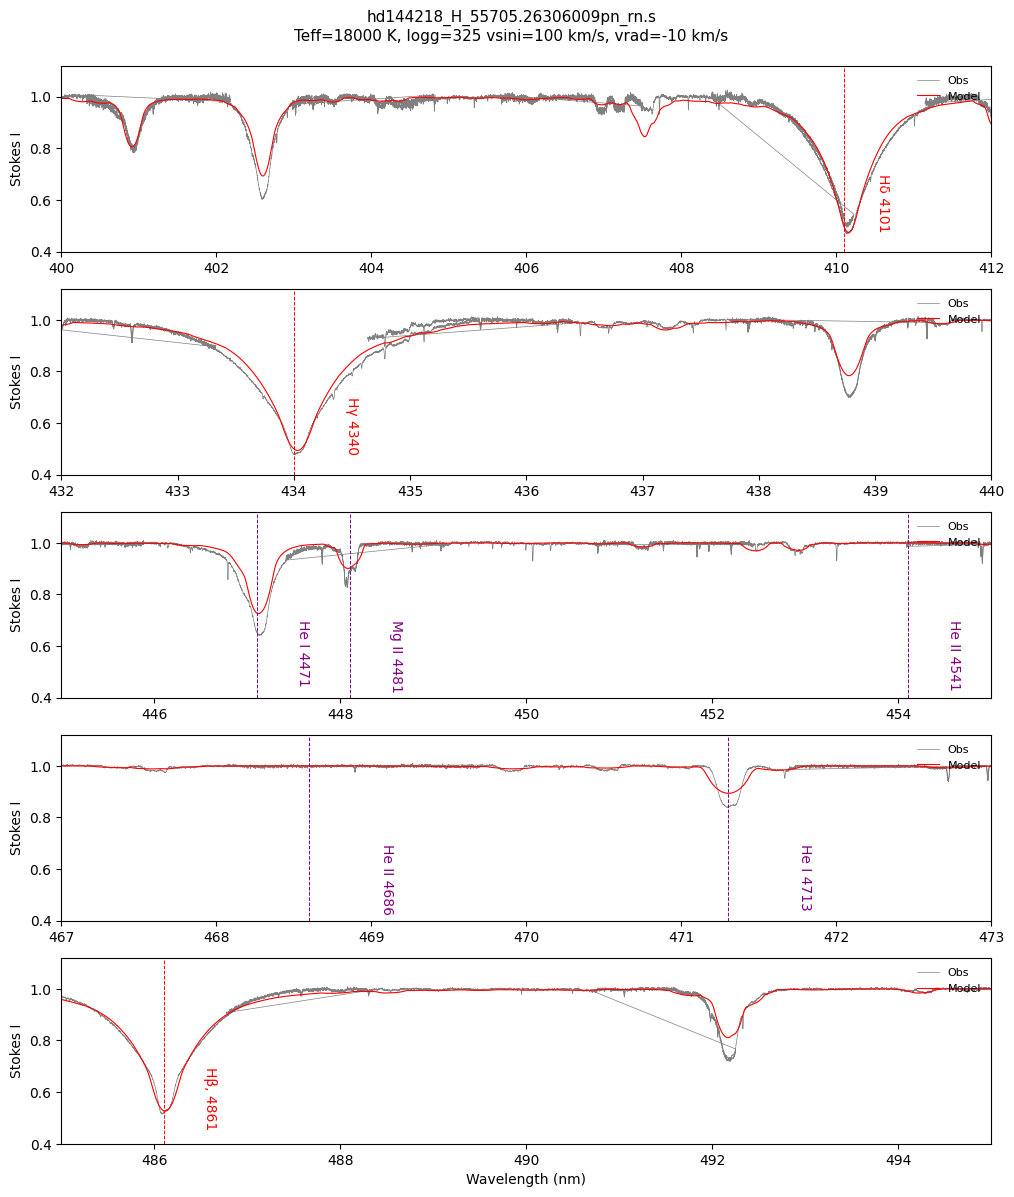

In [ ]:
model = vp.tlusty.read_norm(path_google + my_model_name1)

# Apply radial velocity shift and rotational broadening
model = dopplershift_rotate(
    model,
    params["vrad1"],
    params["vsini1"]
)

# ---------------- Plot ----------------
fig, ax = plt.subplots(
    len(windows),
    1,
    figsize=(12, 2.8 * len(windows)),
    sharey=True
)

for i, (xmin, xmax) in enumerate(windows):

    ax[i].plot(spec.wl,spec.specI,color="grey",lw=0.5, label="Obs")

    ax[i].plot(model.wl / 10,model.specI, color="red",lw=0.8,label="Model")

    ax[i].set_xlim(xmin, xmax)
    ax[i].set_ylim(0.4, 1.12)
    ax[i].set_ylabel("Stokes I")

    # Put legend inside each panel
    ax[i].legend(loc="upper right",fontsize=8,frameon=False)

    # Hydrogen lines
    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl, color="red", ls="--", lw=0.7)
            ax[i].text(
                wl + 0.5,
                0.70,
                label,
                color="red",
                fontsize=10,
                rotation=-90,
                ha="center",
                va="top"
            )

    # Helium / metal lines
    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl, color="purple", ls="--", lw=0.7)
            ax[i].text(
                wl + 0.5,
                0.70,
                label,
                color="purple",
                fontsize=10,
                rotation=-90,
                ha="center",
                va="top"
            )

ax[-1].set_xlabel("Wavelength (nm)")

title = (f"{name}\n"
    f"Teff={params['teff1']} K, logg={params['logg1']} vsini={params['vsini1']} km/s, vrad={params['vrad1']} km/s\n"
)

fig.suptitle(title, fontsize=11, y=0.92)



plt.show()



In [ ]:
def make_single_model(params):

    teff  = params["teff"]
    logg  = params["logg"]
    vsini = params["vsini"]
    vrad  = params["vrad"]
    vturb = params["vturb"]

    # Load TLUSTY model
    model_name = vp.tlusty.galB_path_name.format(
        "vis",
        teff,
        logg,
        str(vturb)
    )

    model = vp.tlusty.read_norm(
        path_google + model_name
    )

    # Apply RV shift + rotational broadening
    model = dopplershift_rotate(
        model,
        vrad,
        vsini
    )

    model_label = (
        rf"$T_{{\rm eff}}={teff}$ K, "
        rf"$\log g={logg/100:.2f}$, "
        rf"$v\sin i={vsini}$ km/s, "
        rf"$v_r={vrad}$ km/s"
    )

    return model, model_label

In [ ]:
# =========================
# DEFINE BASE PARAMETERS
# =========================

base_params = {
"teff": 18000, "logg": 325, "vsini": 60, "vrad":-10,"R2R1": 1.0,"vturb": 2
}


# =========================
# DEFINE PARAMETER TRIALS
# =========================

# Teff  — match He I / He II ionization balance
# log g — Balmer wings (higher log g -> broader wings)
# vsini — widths of helium and metal lines
# vrad  — positions of the spectral lines

trial_updates = [

    ("base", {}),

    # Teff trials
    # ("Teff=16000", {"teff": 16000}),
    # ("Teff=18000", {"teff": 18000}),
    # ("Teff=20000", {"teff": 20000}),
    # log g trials
    # ("logg=325", {"logg": 325}),
    # ("logg=375", {"logg": 375}),

    # vsini trials
    ("vsini=30",  {"vsini": 30,"Teff":20000}),
    ("vsini=80",  {"vsini": 80}),
    ("vsini=120", {"vsini":120,"Teff":20000}),
    # ("vsini=", {"vsini": 125}),
    # vrad trials
    # ("vrad=0",  {"vrad": 0}),
    # ("vrad=40", {"vrad": 40}),

    # Can also change multiple parameters
    # ("T18k_g375", {
    #     "teff": 18000,
    #     "logg": 375
    # }),
]


# Build a full parameter dictionary for every trial
trials = []

for name, updates in trial_updates:

    p = base_params.copy()
    p.update(updates)

    trials.append((name, p))


# =========================
# GENERATE MODELS
# =========================

models = []

for name, params in trials:

    model, model_label = make_single_model(params)

    models.append((name, params, model))


print(f"Generated {len(models)} trial models:")

for name, params, model in models:

    print(f"  {name}: {params}")

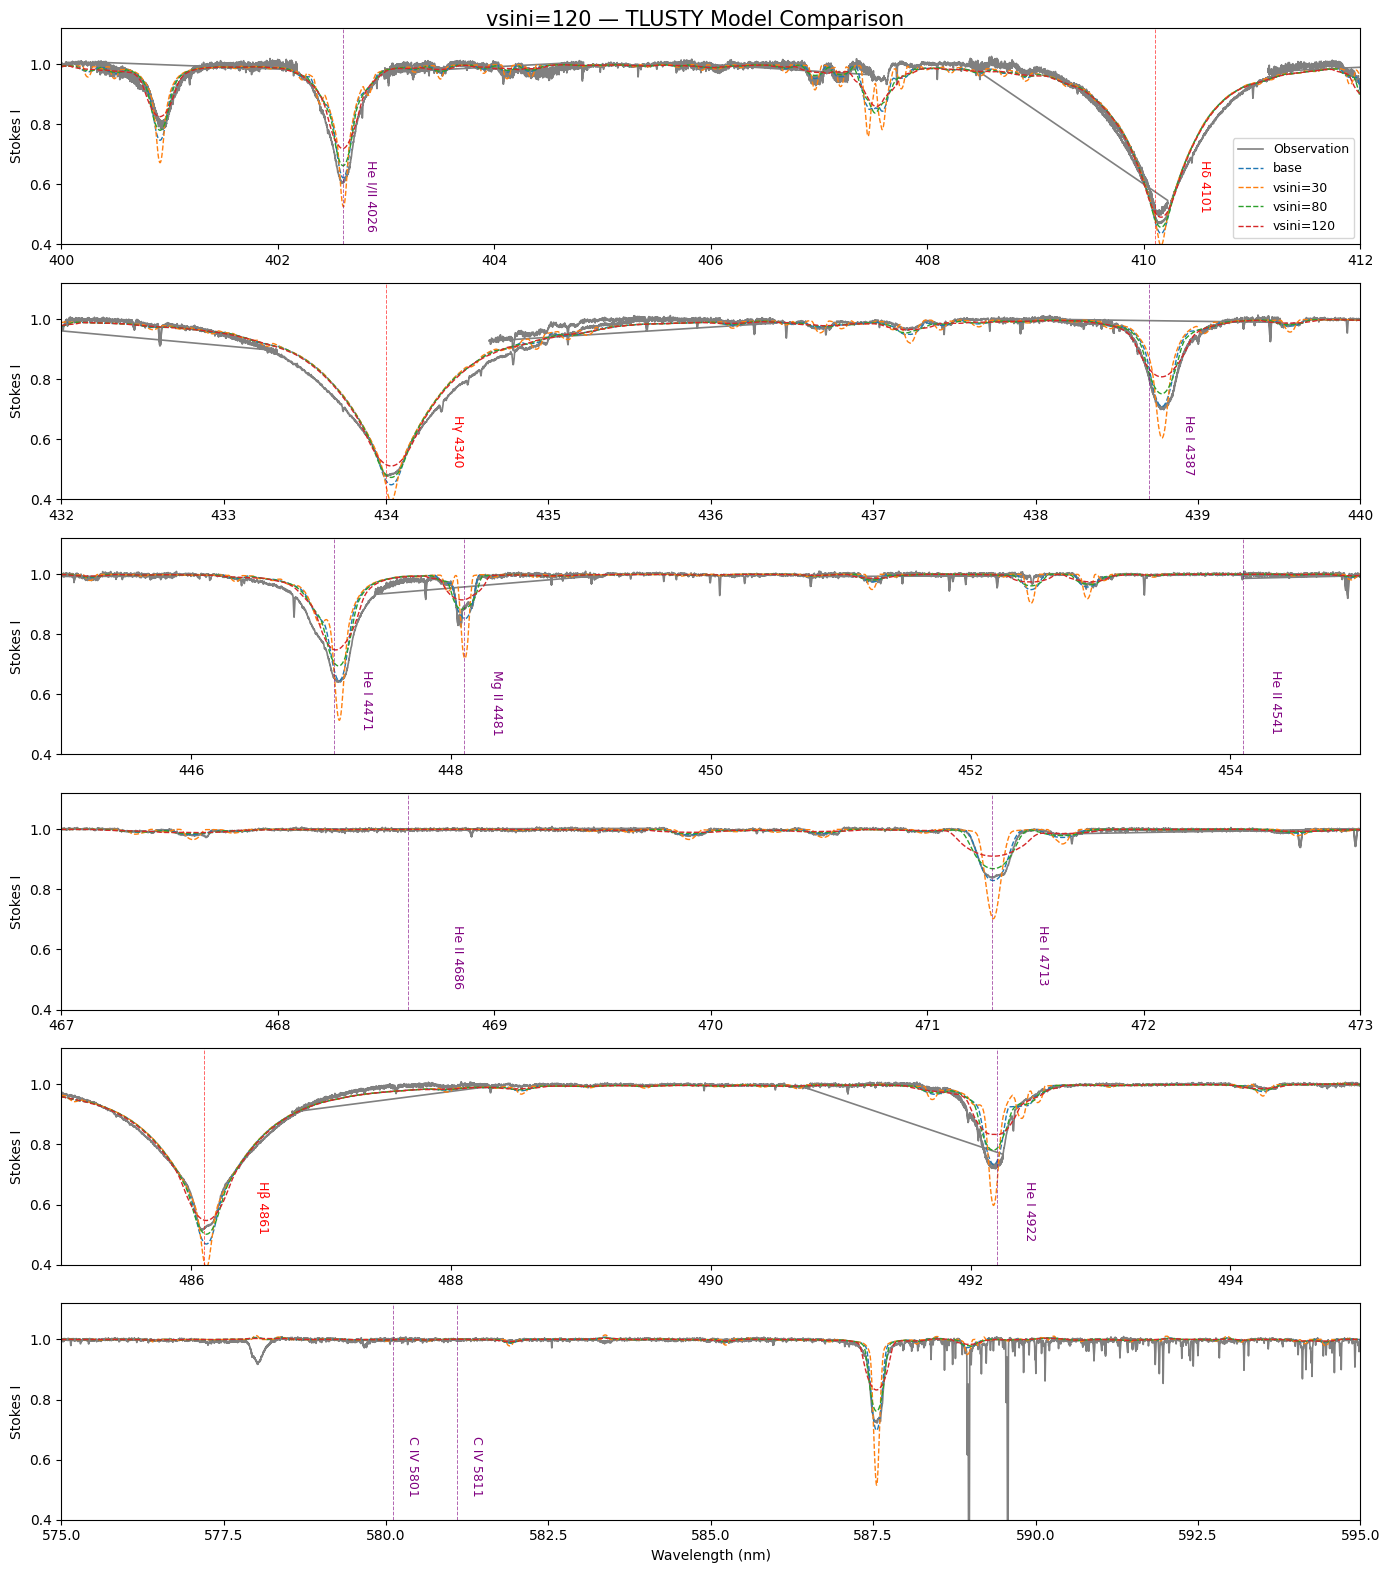

In [66]:
# =========================
# PLOT TRIAL MODELS
# =========================

windows = [(400,412), (432,440), (445,455), (467,473), (485,495),(575,595)]

lines_H = [(410.1,"Hδ 4101"), (434.0,"Hγ 4340"), (486.1,"Hβ 4861")]
lines_He = [(402.6,"He I/II 4026"), (420.0,"He II 4200"), (438.7,"He I 4387"),
            (447.1,"He I 4471"), (448.1,"Mg II 4481"), (454.1,"He II 4541"),
            (468.6,"He II 4686"), (471.3,"He I 4713"), (492.2,"He I 4922"),
            (501.6,"He I 5016"), (580.1,"C IV 5801"), (581.1,"C IV 5811")]

fig, ax = plt.subplots(len(windows), 1, figsize=(14,16), sharey=True)

for i, (xmin, xmax) in enumerate(windows):
    ax[i].plot(spec.wl, spec.specI, color="0.5", lw=1.2, label="Observation")

    for trial_name, params, model in models:
        ax[i].plot(model.wl/10, model.specI, lw=1, label=trial_name,ls='--')

    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl, color="r", ls="--", lw=0.7, alpha=0.6)
            ax[i].text(wl+0.4, 0.68, label, color="r", fontsize=9, rotation=-90, va="top")

    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl, color="purple", ls="--", lw=0.7, alpha=0.6)
            ax[i].text(wl+0.2, 0.68, label, color="purple", fontsize=9, rotation=-90, va="top")

    ax[i].set(xlim=(xmin,xmax), ylim=(0.4,1.12), ylabel="Stokes I")

ax[-1].set_xlabel("Wavelength (nm)")
ax[0].legend(fontsize=9, loc="lower right")
fig.suptitle(f"{name} — TLUSTY Model Comparison", fontsize=15)
plt.tight_layout()
plt.show()